In [41]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

# Beyond LCDM modules
# Linear boost from MGrowth 
from cloelib.cosmology.mgrowth_cosmology import MGrowthLinearPerturbations 
# Tabulated boost from simulations
from cloelib.cosmology.TabulatedBoost_cosmology import TabulatedNonlinearBoost, TabulatedBoostedPerturbations
# Halo model reaction boost 
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

We also compute the boosted perturbations using both the interpolated simulation power spectra ratios and the halo model reaction emulator.

In [5]:
#### LCDM perturbations ####

# DAKAR 2 baseline cosmology 
H0=67.66 
Omega_m0 = 0.311049
Omega_b0 = 0.04897468161869667 
Omega_cdm0 = Omega_m0-Omega_b0 
Omega_k0 = 0.0 
ns = 0.9665 
As = 2e-9
mnu = 0.0001
N_mnu = 1

# Set to LCDM as the boost is taken wrt to LCDM 
w0  = -1
wa  = 0.0

zs = np.linspace(1e-4, 3, 100)

# Load background LCDM cosmology 
lcdm_background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0, wa=wa, 
                               gamma_MG=0.0)


linear_perturbations_emu = HMemuLinearPerturbations(lcdm_background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(lcdm_background, linear_perturbations_emu, zs, log10TAGN=7.8)

In [7]:
#### Tabulated boosted perturbations ####

# Paths to the boost tabulated data 
boost_table  = "../../../../data/DAKAR2/m11_p01_boosts.txt"
#xi = 100; w0ds  = -0.9502; wads  = 0.0975;#  m095_p01_boosts
xi = 100; w0ds  = -1.1001; wads  = 0.0966;#  m11_p01_boosts
# xi = 100; w0ds  = -0.9001; wads  = -0.2025;#  m09_m02_boosts
# xi = 100; w0ds  = -0.9001; wads  = -0.1024;#  m09_m01_boosts

# Tabulated redshifts (corresponding the columns in the boost table)
z_cols = [3.017980, 2.479559, 2.161320, 2.013288, 1.609499, 1.259818, 1.000000, 0.823800, 0.677100, 0.552300
          , 0.444200, 0.349200, 0.264800, 0.188900, 0.120200, 0.057540, 0.000031, 0.0]


mg_boost_tab = TabulatedNonlinearBoost(lcdm_background,linear_perturbations_emu, zs, boost_table, z_cols, high_z_policy='freeze')
boost_interp_tab = mg_boost_tab.MGboost_interp
# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_tab = MGrowthLinearPerturbations(linear_perturbations_emu, nonlinear_perturbations_emu, boost_interp_tab)

In [43]:
#### Halo model reaction and linear boosted perturbations ####
gravity_model = 'ide'

# Provide all expected keys, with harmless defaults for unused ones
mgpars = {
    "fr0": 0.0,
    "omega_rc": 0.0,   # only used for DGP
    "xi": xi,          # Used for all DS cases
    "gamma0": 0.55,    # only used for Linder gamma
    "q1": 0.0          # placeholder, adjust if needed
}

# Load background w0waCDM cosmology 
w0wa_background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0ds, wa=wads, 
                               gamma_MG=0.0)


mg_boost_react = MGemuNonlinearBoost(w0wa_background,linear_perturbations_emu, zs, gravity_model, mgpars, high_z_policy='one')
boost_interp_react = mg_boost_react.MGboost_interp
# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_react = BoostedPerturbations(linear_perturbations_emu, nonlinear_perturbations_emu, boost_interp_react)

# MGrowth linear perturbations 
boosted_perturbations_hmc_mgrowth = MGrowthLinearPerturbations(w0wa_background, linear_perturbations_emu, gravity_model, mgpars)

Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [8]:
# Execute this cell to download the data
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [12]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.photo.redshift_distributions('../likelihood/nz_example.fits')
mixmats_example = el.photo.mixing_matrices('../likelihood/mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

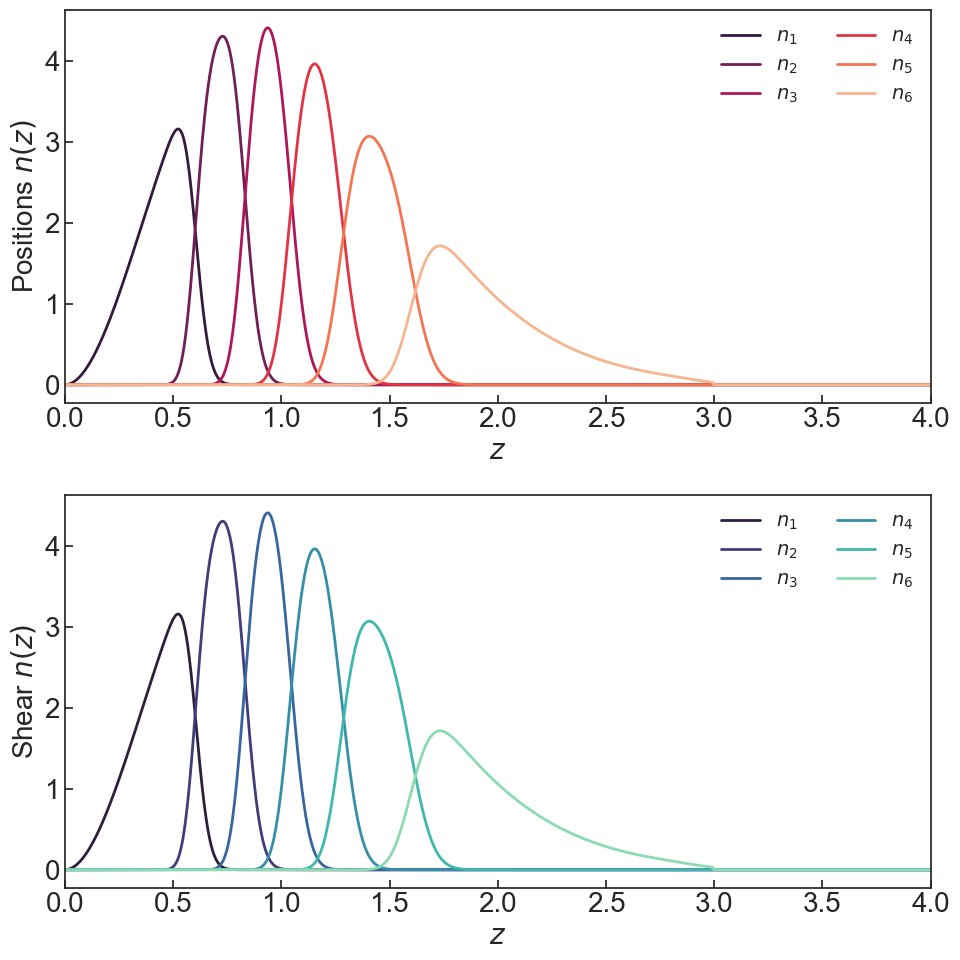

In [10]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Observables: shear and position tracers 

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [44]:
# Tabulated DS  

# Define the tracers
tracer_pos_tab = PositionsTracer(perturbations=boosted_perturbations_hmc_tab, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she_tab = ShearTracer(perturbations=boosted_perturbations_hmc_tab, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

# HMR DS  
# Define the tracers
tracer_pos_react = PositionsTracer(perturbations=boosted_perturbations_hmc_react, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she_react = ShearTracer(perturbations=boosted_perturbations_hmc_react, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})


# Linear DS  
# Define the tracers
tracer_pos_mgrowth = PositionsTracer(perturbations=boosted_perturbations_hmc_mgrowth, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she_mgrowth = ShearTracer(perturbations=boosted_perturbations_hmc_mgrowth, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

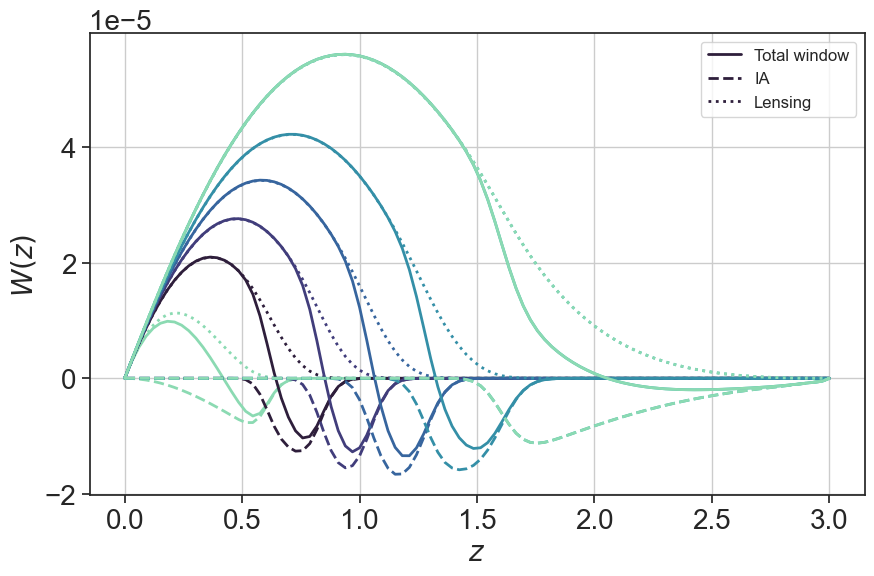

In [16]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(boosted_perturbations_hmc_tab.z, 
             tracer_she_tab.get_window(boosted_perturbations_hmc_tab.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(boosted_perturbations_hmc_tab.z, 
             tracer_she_tab.get_window_IA(boosted_perturbations_hmc_tab.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(boosted_perturbations_hmc_tab.z, 
             tracer_she_tab.get_window_lensing(boosted_perturbations_hmc_tab.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


## Two-point statistics

### Theoretical Predictions: $C_\ell$

We compute angular power spectra initialising the corresponding `cloelib` class. First, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [45]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

# Tabulated boost results
twopoint_pospos_tab = AngularTwoPoint(tracer_pos_tab, tracer_pos_tab)
twopoint_shepos_tab = AngularTwoPoint(tracer_she_tab, tracer_pos_tab)
twopoint_posshe_tab = AngularTwoPoint(tracer_pos_tab, tracer_she_tab)
twopoint_sheshe_tab = AngularTwoPoint(tracer_she_tab, tracer_she_tab)

cells_tab ={**twopoint_pospos_tab.get_Cl(ells, 0, boosted_perturbations_hmc_tab.k)
, **twopoint_shepos_tab.get_Cl(ells, 0, boosted_perturbations_hmc_tab.k)
, **twopoint_sheshe_tab.get_Cl(ells, 0, boosted_perturbations_hmc_tab.k)}


twopoint_pospos_react = AngularTwoPoint(tracer_pos_react, tracer_pos_react)
twopoint_shepos_react = AngularTwoPoint(tracer_she_react, tracer_pos_react)
twopoint_posshe_react = AngularTwoPoint(tracer_pos_react, tracer_she_react)
twopoint_sheshe_react = AngularTwoPoint(tracer_she_react, tracer_she_react)

cells_react ={**twopoint_pospos_react.get_Cl(ells, 0, boosted_perturbations_hmc_react.k)
, **twopoint_shepos_react.get_Cl(ells, 0, boosted_perturbations_hmc_react.k)
, **twopoint_sheshe_react.get_Cl(ells, 0, boosted_perturbations_hmc_react.k)}



twopoint_pospos_mgrowth = AngularTwoPoint(tracer_pos_mgrowth, tracer_pos_mgrowth)
twopoint_shepos_mgrowth = AngularTwoPoint(tracer_she_mgrowth, tracer_pos_mgrowth)
twopoint_posshe_mgrowth = AngularTwoPoint(tracer_pos_mgrowth, tracer_she_mgrowth)
twopoint_sheshe_mgrowth = AngularTwoPoint(tracer_she_mgrowth, tracer_she_mgrowth)

cells_mgrowth ={**twopoint_pospos_mgrowth.get_Cl(ells, 0, boosted_perturbations_hmc_mgrowth.k)
, **twopoint_shepos_mgrowth.get_Cl(ells, 0, boosted_perturbations_hmc_mgrowth.k)
, **twopoint_sheshe_mgrowth.get_Cl(ells, 0, boosted_perturbations_hmc_mgrowth.k)}

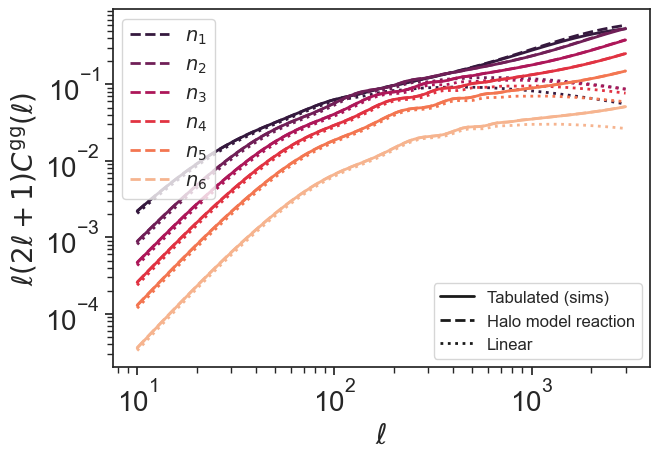

In [62]:
from matplotlib.lines import Line2D

plt.figure(figsize=(7,5))
palette = sns.color_palette("rocket", len(nz_example.keys()))

for i in range(6):
    c = palette[i]
    ells = cells_tab['POS','POS',i+1,i+1].ell
    weight = ells*(2*ells+1)

    plt.loglog(ells, weight*cells_tab['POS','POS',i+1,i+1],
               color=c, lw=2)
    
    plt.loglog(ells, weight*cells_react['POS','POS',i+1,i+1],
               label=f'$n_{{{i+1}}}$', color=c, lw=2, ls='--')

    plt.loglog(ells, weight*cells_mgrowth['POS','POS',i+1,i+1],
               color=c, lw=2, ls=':')

# -------- First legend (your bin labels) --------
leg1 = plt.legend(fontsize=14, loc='upper left')

# -------- Second legend (line-style explanation) --------
style_handles = [
    Line2D([0],[0], color='k', lw=2, ls='-', label='Tabulated (sims)'),
    Line2D([0],[0], color='k', lw=2, ls='--',  label='Halo model reaction'),
    Line2D([0],[0], color='k', lw=2, ls=':',  label='Linear'),
]

leg2 = plt.legend(handles=style_handles, fontsize=12, loc='lower right')

# Make sure both legends stay on the figure
plt.gca().add_artist(leg1)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$')
plt.tight_layout()
plt.show()

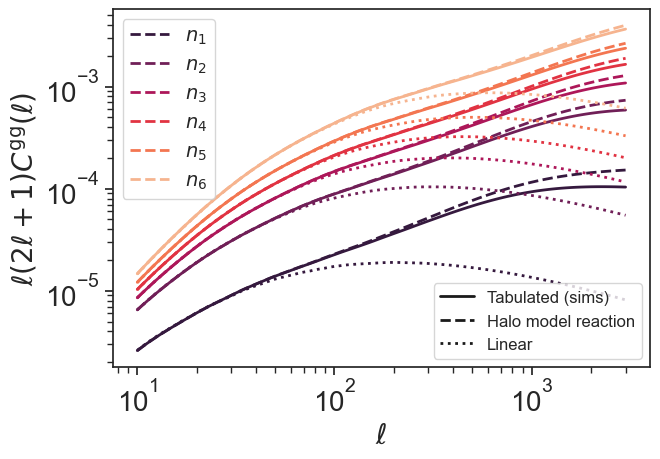

In [63]:
from matplotlib.lines import Line2D

plt.figure(figsize=(7,5))
palette = sns.color_palette("rocket", len(nz_example.keys()))

for i in range(6):
    c = palette[i]
    ells = cells_tab['SHE','SHE',i+1,i+1].ell
    W = ells * (2*ells + 1)

    # Solid: tabulated sims
    plt.loglog(
        ells, W * cells_tab['SHE','SHE',i+1,i+1][0,0],
        color=c, lw=2, ls='-'
    )

    # Dashed: reaction
    plt.loglog(
        ells, W * cells_react['SHE','SHE',i+1,i+1][0,0],
        label=f'$n_{{{i+1}}}$', color=c, lw=2, ls='--'
    )

    # Dotted: linear / mgrowth
    plt.loglog(
        ells, W * cells_mgrowth['SHE','SHE',i+1,i+1][0,0],
        color=c, lw=2, ls=':'
    )

# ---------------- First legend (bins) ----------------
leg1 = plt.legend(fontsize=14, loc='upper left')

# ---------------- Second legend (line styles) ----------------
style_handles = [
    Line2D([0],[0], color='k', lw=2, ls='-', label='Tabulated (sims)'),
    Line2D([0],[0], color='k', lw=2, ls='--',  label='Halo model reaction'),
    Line2D([0],[0], color='k', lw=2, ls=':',  label='Linear'),
]

leg2 = plt.legend(handles=style_handles, fontsize=12, loc='lower right')

# Keep the first legend visible
plt.gca().add_artist(leg1)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1) C^{\rm gg}(\ell)$')
plt.tight_layout()
plt.show()

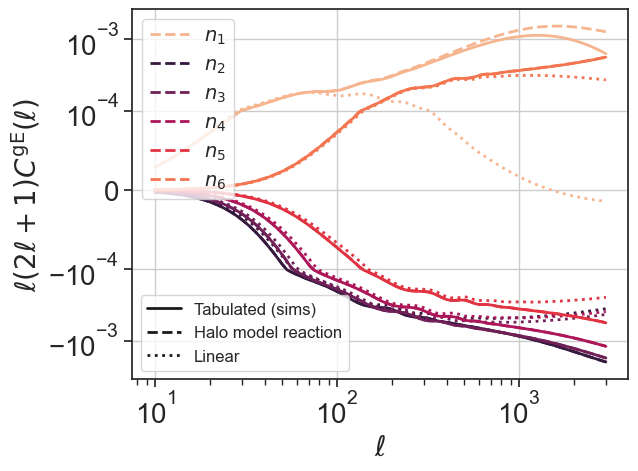

<Figure size 640x480 with 0 Axes>

In [64]:
for i in range(0, 6):
    ells = cells_tab['POS', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells_tab['POS', 'SHE', i+1, i+1][0], linestyle='solid', linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
    plt.loglog(ells, ells*(2*ells+1)*cells_react['POS', 'SHE', i+1, i+1][0], linestyle='dashed', label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
    plt.loglog(ells, ells*(2*ells+1)*cells_mgrowth['POS', 'SHE', i+1, i+1][0], linestyle='dotted', linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])


# ---------------- First legend (bins) ----------------
leg1 = plt.legend(fontsize=14, loc='upper left')

# ---------------- Second legend (line styles) ----------------
style_handles = [
    Line2D([0],[0], color='k', lw=2, ls='-', label='Tabulated (sims)'),
    Line2D([0],[0], color='k', lw=2, ls='--',  label='Halo model reaction'),
    Line2D([0],[0], color='k', lw=2, ls=':',  label='Linear'),
]

leg2 = plt.legend(handles=style_handles, fontsize=12, loc='lower left')

# Keep the first legend visible
plt.gca().add_artist(leg1)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$')
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')

plt.grid(True)
plt.show()

plt.tight_layout()
plt.show()

### Theoretical Predictions: pseudo-$C_\ell$

Now, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [65]:
cells_tab_PP = twopoint_pospos_tab.get_pseudo_Cl(0, boosted_perturbations_hmc_tab.k,mixmats_example)
cells_tab_SS = twopoint_sheshe_tab.get_pseudo_Cl(nl, boosted_perturbations_hmc_tab.k,mixmats_example)
cells_tab_PS = twopoint_shepos_tab.get_pseudo_Cl(nl, boosted_perturbations_hmc_tab.k,mixmats_example)

cells_react_PP = twopoint_pospos_react.get_pseudo_Cl(0, boosted_perturbations_hmc_react.k,mixmats_example)
cells_react_SS = twopoint_sheshe_react.get_pseudo_Cl(nl, boosted_perturbations_hmc_react.k,mixmats_example)
cells_react_PS = twopoint_shepos_react.get_pseudo_Cl(nl, boosted_perturbations_hmc_react.k,mixmats_example)

cells_mgrowth_PP = twopoint_pospos_mgrowth.get_pseudo_Cl(0, boosted_perturbations_hmc_mgrowth.k,mixmats_example)
cells_mgrowth_SS = twopoint_sheshe_mgrowth.get_pseudo_Cl(nl, boosted_perturbations_hmc_mgrowth.k,mixmats_example)
cells_mgrowth_PS = twopoint_shepos_mgrowth.get_pseudo_Cl(nl, boosted_perturbations_hmc_mgrowth.k,mixmats_example)

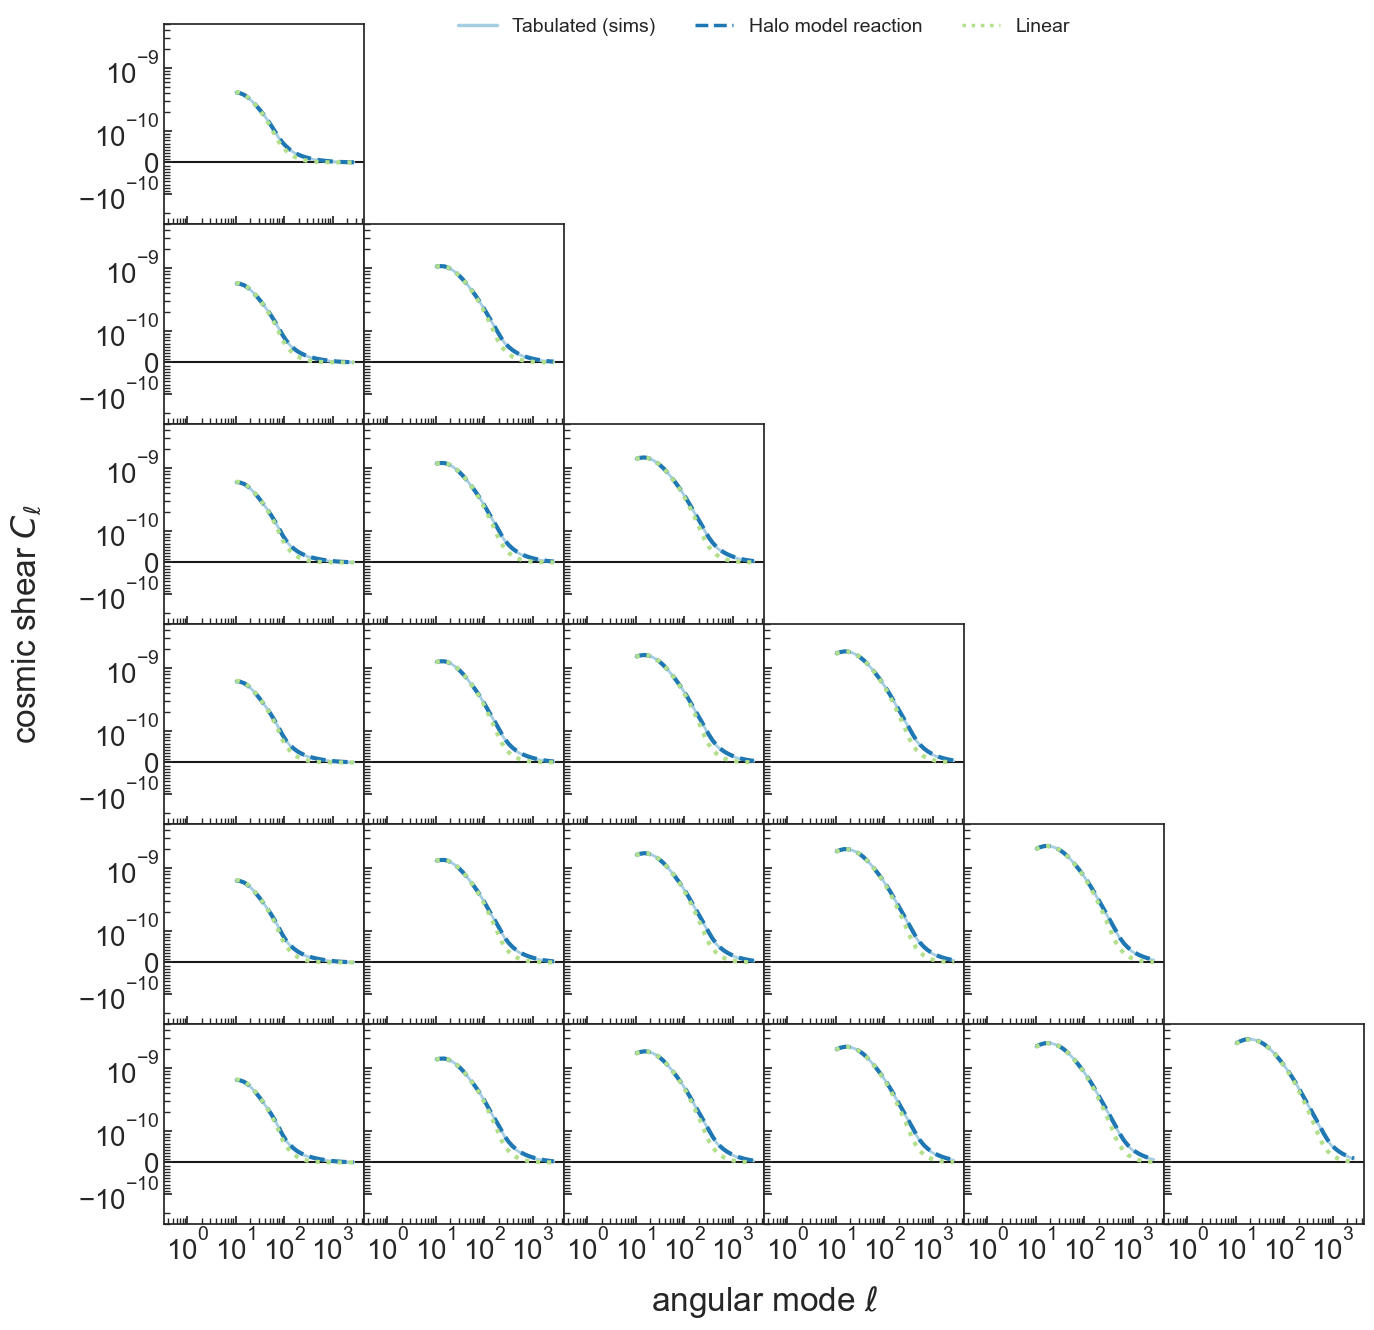

In [69]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            cells_tab_SS["SHE", "SHE",i, j].ell, cells_tab_SS["SHE", "SHE",i, j][0, 0], c="C0", lw=2.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            cells_react_SS["SHE", "SHE",i, j].ell, cells_react_SS["SHE", "SHE",i, j][0, 0], c="C1", lw=3.0, zorder=4.0, linestyle='dashed'
        )
        ax[j - 1, i - 1].plot(
            cells_mgrowth_SS["SHE", "SHE",i, j].ell, cells_mgrowth_SS["SHE", "SHE",i, j][0, 0], c="C2", lw=3.0, zorder=4.0, linestyle='dotted'
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")


# Style legend: solid, dashed, dotted
style_handles = [
    Line2D([0],[0], color='C0', lw=2.5, ls='-',  label='Tabulated (sims)'),
    Line2D([0],[0], color='C1', lw=2.5, ls='--', label='Halo model reaction'),
    Line2D([0],[0], color='C2', lw=2.5, ls=':',  label='Linear'),
]

# Place legend just outside the figure
fig.legend(
    handles=style_handles,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=14,
    frameon=False
)

plt.show()

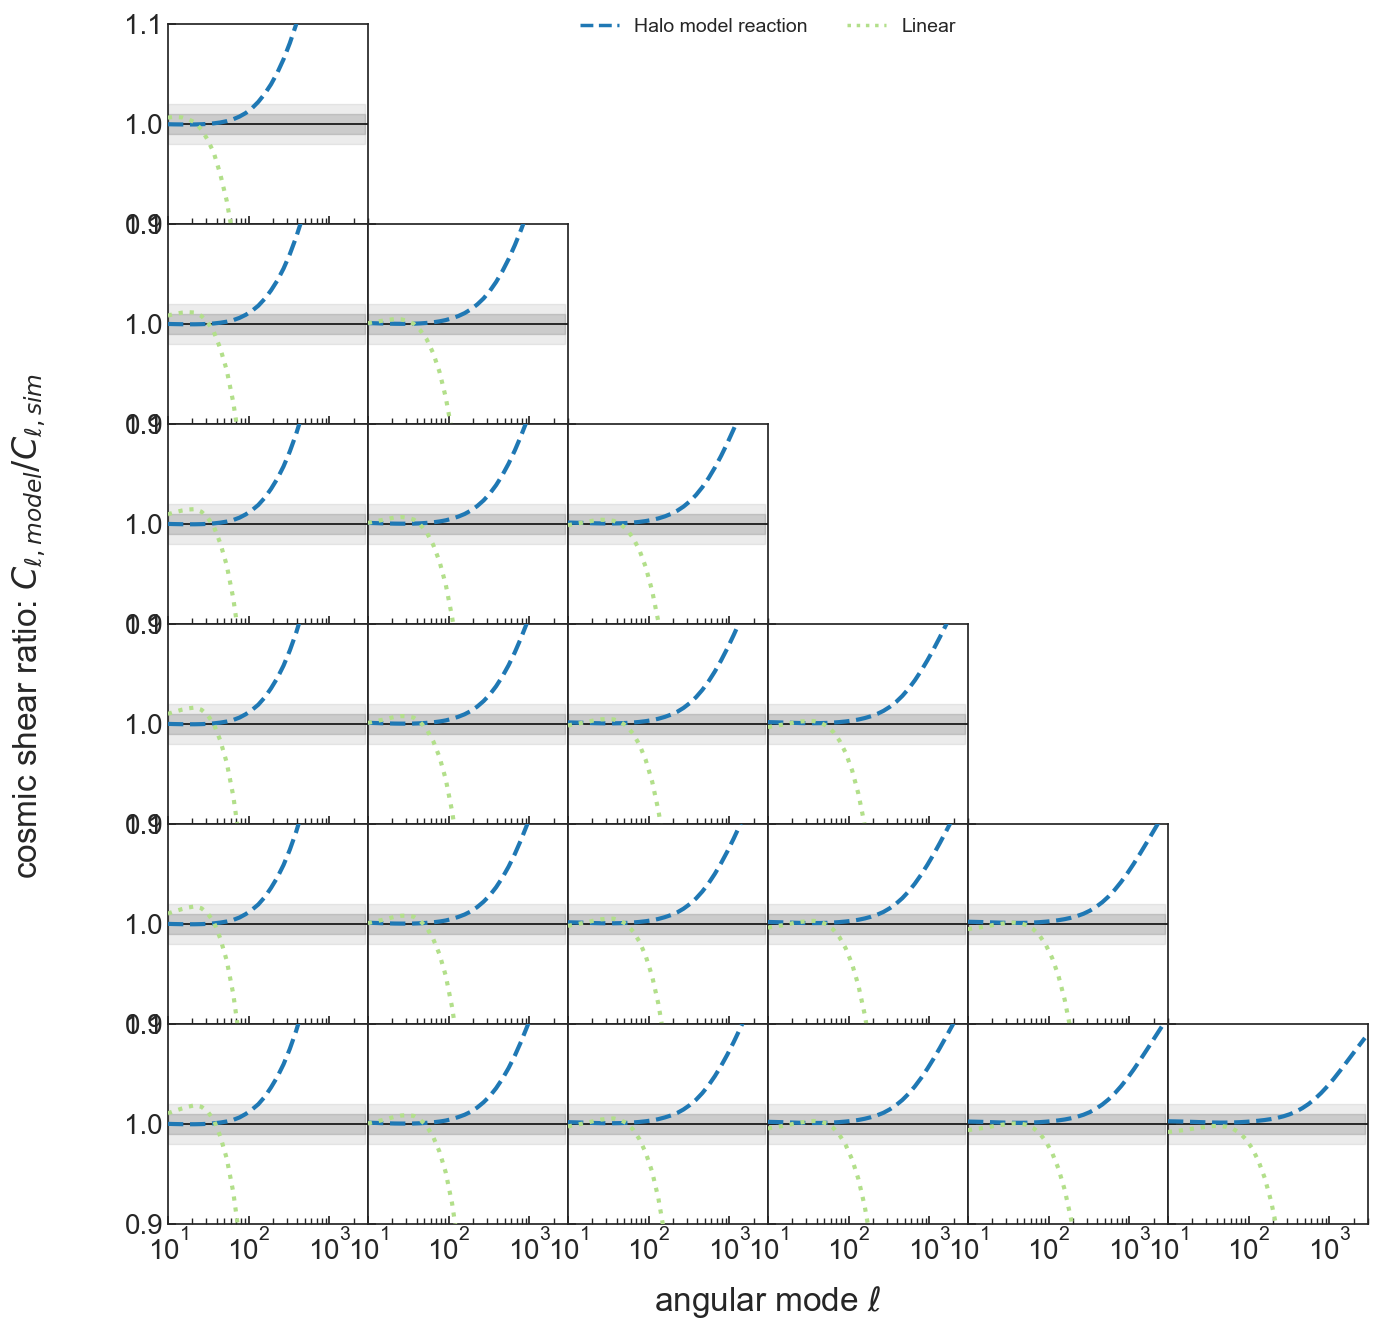

In [72]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")

    for j in range(i, 7):

        # --- Extract data ---
        ell = cells_tab_SS["SHE","SHE",i,j].ell
        ratio = (
            cells_react_SS["SHE","SHE",i,j][0,0]/ cells_tab_SS["SHE","SHE",i,j][0,0] 
        )

        ratio_linear = (
            cells_mgrowth_SS["SHE","SHE",i,j][0,0]/ cells_tab_SS["SHE","SHE",i,j][0,0] 
        )        

        # --- Error bands (draw first, behind the data) ---
        ax[j - 1, i - 1].fill_between(
            ell, 0.98, 1.02, color="gray", alpha=0.15, zorder=1
        )  # ±2%

        ax[j - 1, i - 1].fill_between(
            ell, 0.99, 1.01, color="gray", alpha=0.30, zorder=2
        )  # ±1%

        # --- Ratio curve ---
        ax[j - 1, i - 1].plot(
            ell, ratio,
            c="C1", lw=3.0, zorder=4.0, linestyle="dashed"
        )

        # --- Linear ratio curve ---
        ax[j - 1, i - 1].plot(
            ell, ratio_linear,
            c="C2", lw=3.0, zorder=4.0, linestyle="dotted"
        )
        
        # --- Zero line (or unity line depending on definition) ---
        ax[j - 1, i - 1].axhline(1.0, c="k", lw=1.3, zorder=3)  # unity reference

        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

# --- Shared axes settings ---
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(10, 3000)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(numticks=99, subs=np.arange(0.1, 1.0, 0.1))
ax[0, 0].set_ylim(0.9, 1.1)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear ratio: $C_{\\ell,model}/C_{\\ell,sim}$ ", x=-0.1, ha="right")


# Style legend: solid, dashed, dotted
style_handles = [
    Line2D([0],[0], color='C1', lw=2.5, ls='--', label='Halo model reaction'),
    Line2D([0],[0], color='C2', lw=2.5, ls=':',  label='Linear'),
]

# Place legend just outside the figure
fig.legend(
    handles=style_handles,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=14,
    frameon=False
)

plt.savefig("shear_grid.png", dpi=300, bbox_inches='tight')
plt.show()